In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('greendestination.csv')   # Make sure your file name matches exactly
print(" Data Loaded Successfully!\n")

print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())


 Data Loaded Successfully!

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction

In [3]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())



Missing Values per Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurre

In [5]:
if 'Attrition' in df.columns:
    attrition_rate = (df['Attrition'].value_counts(normalize=True).get('Yes', 0)) * 100
    print(f"\n Attrition Rate: {attrition_rate:.2f}%")
else:
    print("\n⚠️ Column 'Attrition' not found. Please verify column names.")


 Attrition Rate: 16.12%


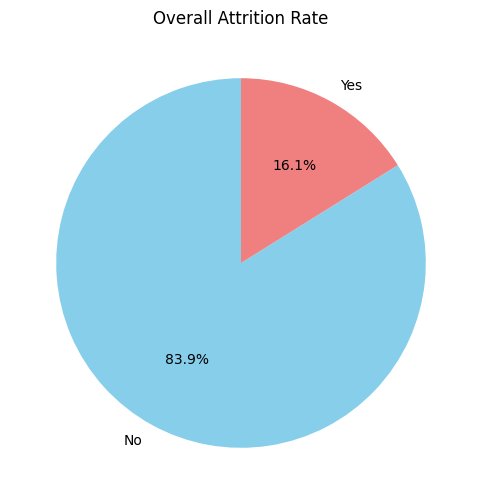

In [6]:
plt.figure(figsize=(6,6))
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Overall Attrition Rate')
plt.ylabel('')
plt.show()

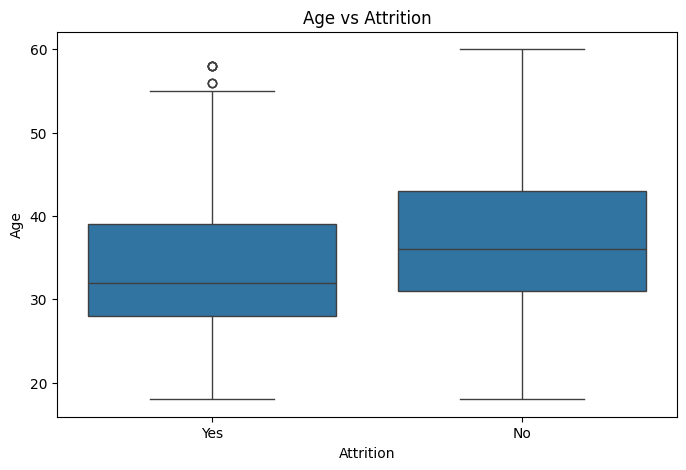

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

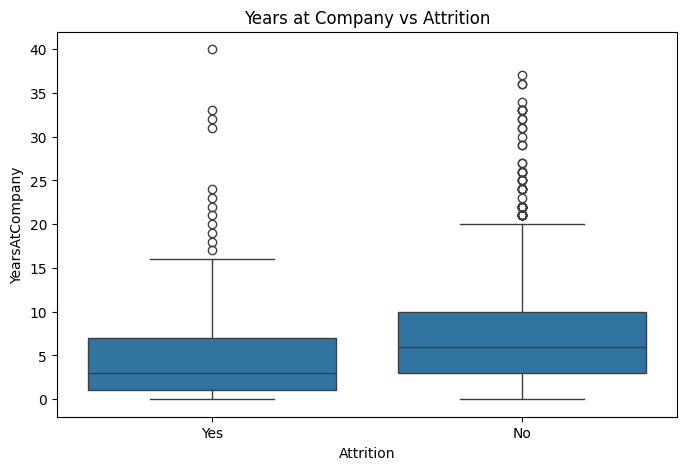

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company vs Attrition')
plt.show()

In [9]:
if 'Income' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Attrition', y='Income', data=df)
    plt.title('Income vs Attrition')
    plt.show()


In [10]:
df['Attrition_flag'] = df['Attrition'].map({'Yes':1, 'No':0})

In [13]:
features = ['Age', 'YearsAtCompany', 'MonthlyIncome']
X = df[features]
y = df['Attrition_flag']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [16]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print("\n📈 Logistic Regression Results:")
print(classification_report(y_test, y_pred))



📈 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       380
           1       0.00      0.00      0.00        61

    accuracy                           0.86       441
   macro avg       0.43      0.50      0.46       441
weighted avg       0.74      0.86      0.80       441



C:\Users\likit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\likit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\likit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

In [18]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print("\n Feature Influence on Attrition:")
print(coef_df)


 Feature Influence on Attrition:
          Feature  Coefficient
2   MonthlyIncome    -0.000062
0             Age    -0.034481
1  YearsAtCompany    -0.055401


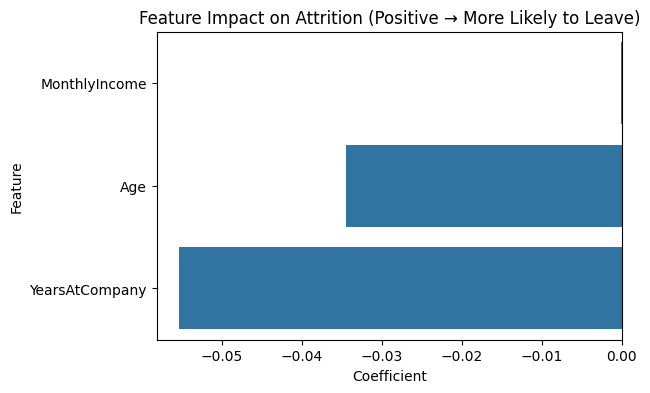

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Impact on Attrition (Positive → More Likely to Leave)')
plt.show()